[*********************100%***********************]  1 of 1 completed


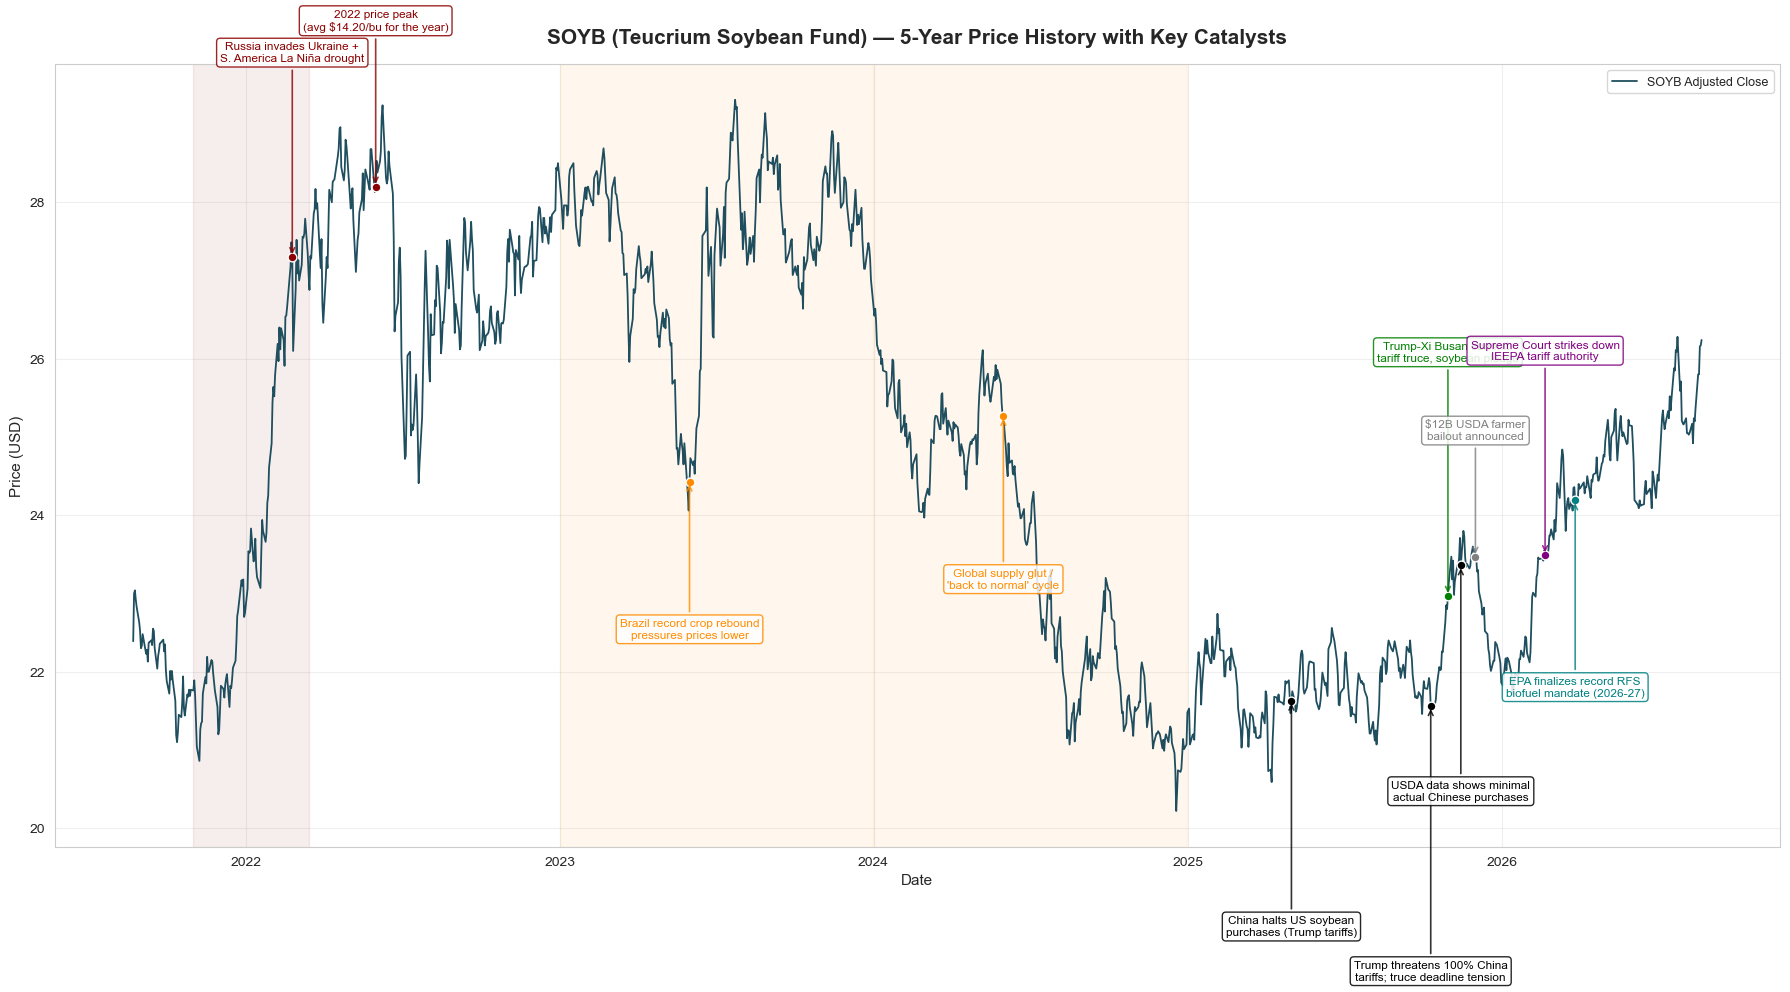

Data range: 2021-08-23 to 2026-08-21
Price range: $20.22 - $29.31


In [1]:
"""
SOYB (Teucrium Soybean Fund) — 5-Year Retrospective Catalyst Chart
====================================================================
Fetches 5 years of daily adjusted-close price data for SOYB via yfinance
and plots it with annotated callouts marking the major macro / geopolitical
/ climate catalysts researched for the period (2021-2026).

Requirements:
    pip install yfinance matplotlib seaborn pandas

Note: Not executed in this environment (no network access here) —
run locally and adjust annotation y-offsets once you see the real
price scale returned by yfinance.
"""

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# ----------------------------------------------------------------------
# 1. Fetch data
# ----------------------------------------------------------------------
TICKER = "SOYB"
PERIOD_YEARS = 5

df = yf.download(TICKER, period=f"{PERIOD_YEARS}y", interval="1d", auto_adjust=True)
df = df.dropna()

if df.empty:
    raise RuntimeError(
        f"No data returned for {TICKER}. Check ticker validity and network connection."
    )

# Flatten MultiIndex columns if yfinance returns them (common with single-ticker downloads)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

price_col = "Close"  # auto_adjust=True makes 'Close' the adjusted close

# ----------------------------------------------------------------------
# 2. Define catalyst annotations
# ----------------------------------------------------------------------
# Each entry: (date_str, label, vertical_offset_in_price_units, arrow_color, shaded_span_days_or_None)
catalysts = [
    ("2022-02-24", "Russia invades Ukraine +\nS. America La Niña drought",
     2.5, "darkred", ("2021-11-01", "2022-03-15")),
    ("2022-06-01", "2022 price peak\n(avg $14.20/bu for the year)",
     2.0, "darkred", None),
    ("2023-06-01", "Brazil record crop rebound\npressures prices lower",
     -2.0, "darkorange", ("2023-01-01", "2023-12-31")),
    ("2024-06-01", "Global supply glut /\n'back to normal' cycle",
     -2.2, "darkorange", ("2024-01-01", "2024-12-31")),
    ("2025-05-01", "China halts US soybean\npurchases (Trump tariffs)",
     -3.0, "black", None),
    ("2025-10-10", "Trump threatens 100% China\ntariffs; truce deadline tension",
     -3.5, "black", None),
    ("2025-10-30", "Trump-Xi Busan summit:\ntariff truce, soybean pledge",
     3.0, "green", None),
    ("2025-11-14", "USDA data shows minimal\nactual Chinese purchases",
     -3.0, "black", None),
    ("2025-12-01", "$12B USDA farmer\nbailout announced",
     1.5, "gray", None),
    ("2026-02-20", "Supreme Court strikes down\nIEEPA tariff authority",
     2.5, "purple", None),
    ("2026-03-27", "EPA finalizes record RFS\nbiofuel mandate (2026-27)",
     -2.5, "teal", None),
    ("2026-09-24", "Xi Jinping state visit —\nTrump meeting (competition window)",
     3.0, "green", None),
]

# ----------------------------------------------------------------------
# 3. Plot
# ----------------------------------------------------------------------
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(18, 10))

ax.plot(df.index, df[price_col], color="#1f4e5f", linewidth=1.3, label="SOYB Adjusted Close")

y_min, y_max = df[price_col].min(), df[price_col].max()
y_range = y_max - y_min

for date_str, label, offset, color, span in catalysts:
    date = pd.Timestamp(date_str)
    if date < df.index.min() or date > df.index.max():
        continue  # skip catalysts outside the fetched window

    # Find nearest actual trading-day price for the marker
    nearest_idx = df.index.get_indexer([date], method="nearest")[0]
    nearest_date = df.index[nearest_idx]
    nearest_price = df[price_col].iloc[nearest_idx]

    # Marker dot
    ax.scatter(nearest_date, nearest_price, color=color, s=40, zorder=5, edgecolor="white")

    # Annotation with arrow
    text_y = nearest_price + offset
    ax.annotate(
        label,
        xy=(nearest_date, nearest_price),
        xytext=(nearest_date, text_y),
        fontsize=8.5,
        ha="center",
        color=color,
        arrowprops=dict(arrowstyle="->", color=color, lw=1.2, alpha=0.8),
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=color, alpha=0.85),
        zorder=6,
    )

    # Optional shaded span (e.g. a multi-month drought/glut period)
    if span is not None:
        start, end = pd.Timestamp(span[0]), pd.Timestamp(span[1])
        ax.axvspan(start, end, color=color, alpha=0.07)

# ----------------------------------------------------------------------
# 4. Formatting
# ----------------------------------------------------------------------
ax.set_title(
    f"{TICKER} (Teucrium Soybean Fund) — 5-Year Price History with Key Catalysts",
    fontsize=15, fontweight="bold", pad=15,
)
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Price (USD)", fontsize=11)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))

ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("soyb_5yr_catalyst_chart.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Data range: {df.index.min().date()} to {df.index.max().date()}")
print(f"Price range: ${df[price_col].min():.2f} - ${df[price_col].max():.2f}")

[*********************100%***********************]  1 of 1 completed


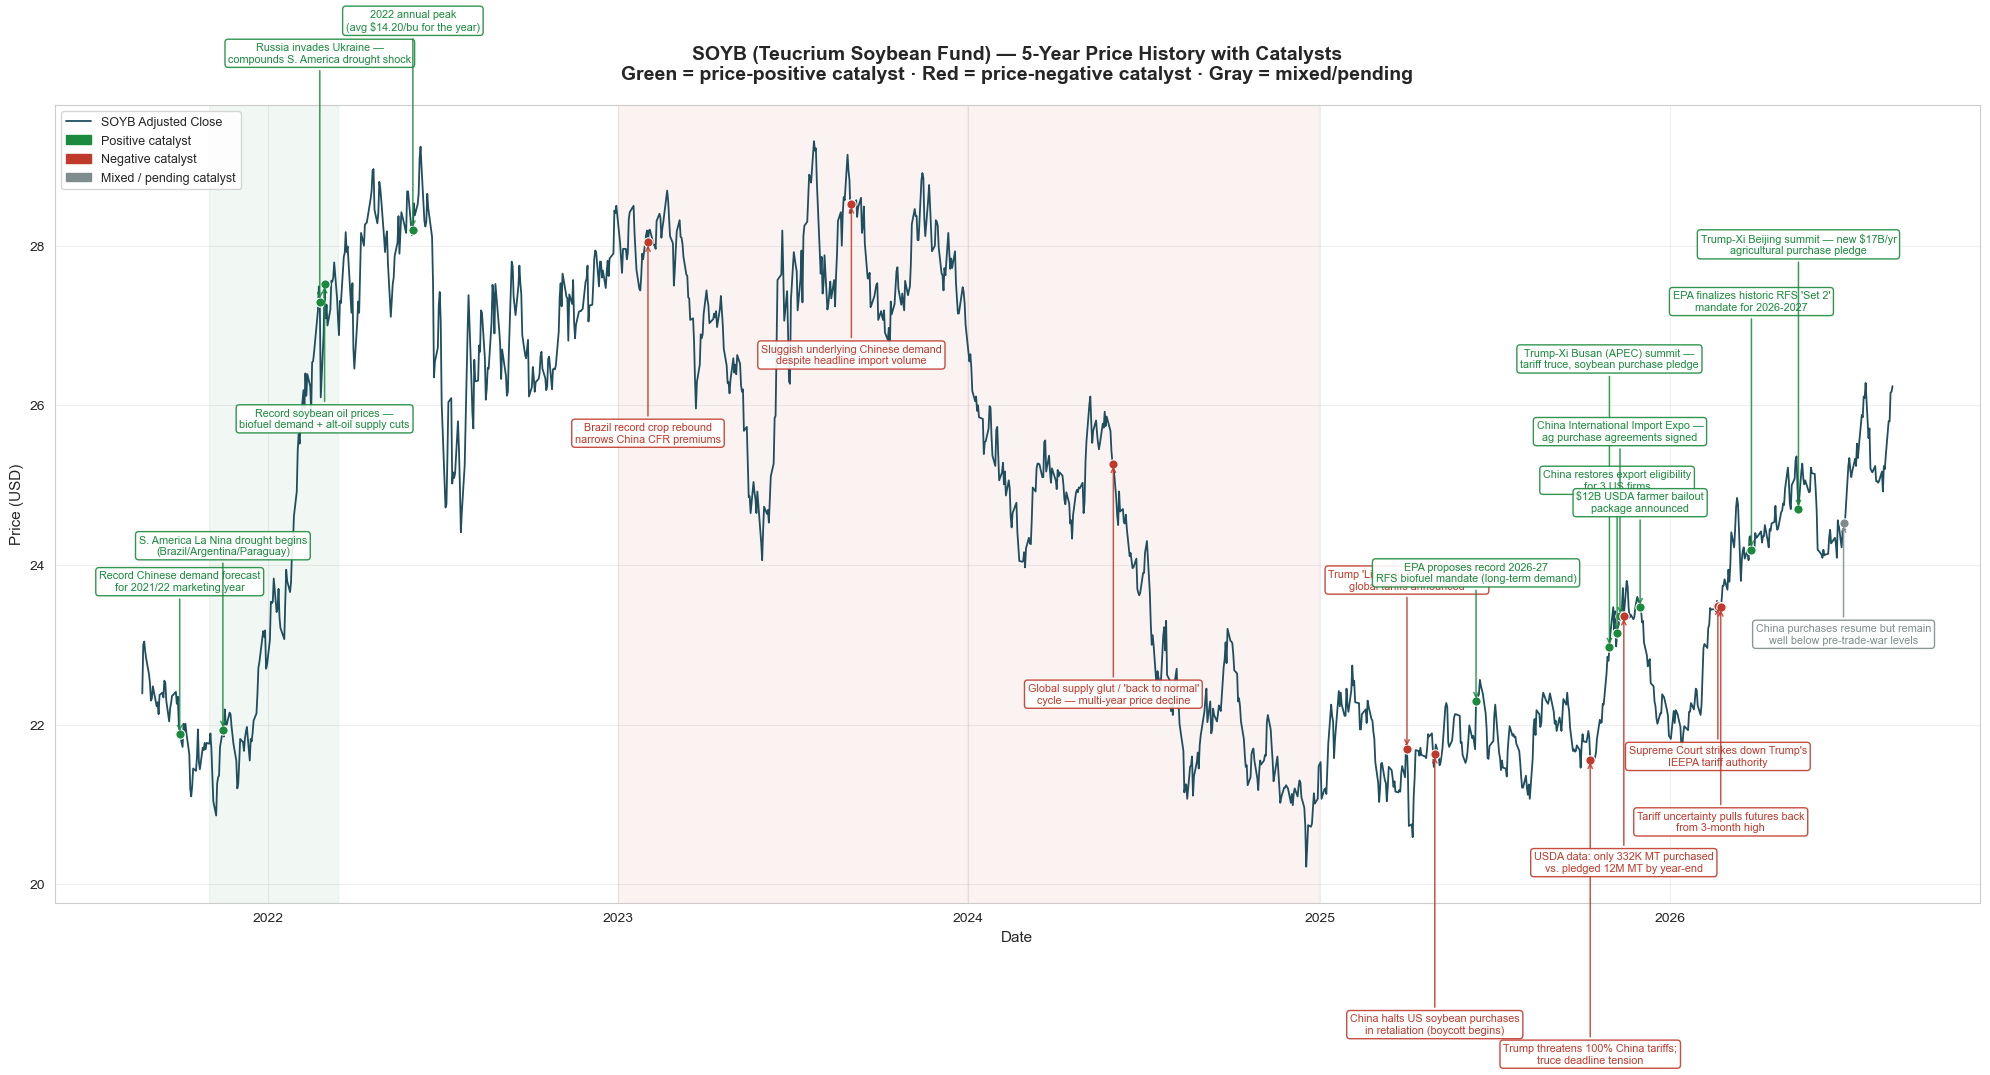

Data range: 2021-08-23 to 2026-08-21
Price range: $20.22 - $29.31
Total catalysts plotted: 22


In [2]:
"""
SOYB (Teucrium Soybean Fund) — 5-Year Retrospective Catalyst Chart
====================================================================
Fetches 5 years of daily adjusted-close price data for SOYB via yfinance
and plots it with annotated callouts marking the major macro / geopolitical
/ climate catalysts researched for the period (2021-2026).

Color coding:
    GREEN = catalyst that was price-positive for soybeans / SOYB
    RED   = catalyst that was price-negative for soybeans / SOYB
    GRAY  = mixed / uncertain / pending catalyst (direction not yet resolved)

Requirements:
    pip install yfinance matplotlib seaborn pandas

Note: Not executed in this environment (no network access here) —
run locally and adjust annotation y-offsets once you see the real
price scale returned by yfinance.
"""

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns

# ----------------------------------------------------------------------
# 1. Fetch data
# ----------------------------------------------------------------------
TICKER = "SOYB"
PERIOD_YEARS = 5

df = yf.download(TICKER, period=f"{PERIOD_YEARS}y", interval="1d", auto_adjust=True)
df = df.dropna()

if df.empty:
    raise RuntimeError(
        f"No data returned for {TICKER}. Check ticker validity and network connection."
    )

# Flatten MultiIndex columns if yfinance returns them (common with single-ticker downloads)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

price_col = "Close"  # auto_adjust=True makes 'Close' the adjusted close

# ----------------------------------------------------------------------
# 2. Define catalyst annotations
# ----------------------------------------------------------------------
# Each entry: (date_str, label, vertical_offset_in_price_units, direction, shaded_span_or_None)
# direction: "positive" -> green, "negative" -> red, "neutral" -> gray
DIRECTION_COLORS = {
    "positive": "#1a8a3d",   # green
    "negative": "#c0392b",   # red
    "neutral":  "#7f8c8d",   # gray
}

catalysts = [
    # --- 2021 ---
    ("2021-10-01", "Record Chinese demand forecast\nfor 2021/22 marketing year",
     1.8, "positive", None),

    # --- Late 2021 - early 2022: La Nina drought + Ukraine war ---
    ("2021-11-15", "S. America La Nina drought begins\n(Brazil/Argentina/Paraguay)",
     2.2, "positive", ("2021-11-01", "2022-03-15")),
    ("2022-02-24", "Russia invades Ukraine —\ncompounds S. America drought shock",
     3.0, "positive", None),
    ("2022-06-01", "2022 annual peak\n(avg $14.20/bu for the year)",
     2.5, "positive", None),

    # --- 2021-22: biofuel / soy oil ---
    ("2022-03-01", "Record soybean oil prices —\nbiofuel demand + alt-oil supply cuts",
     -1.8, "positive", None),

    # --- 2023: Brazil rebound, weakening demand ---
    ("2023-02-01", "Brazil record crop rebound\nnarrows China CFR premiums",
     -2.5, "negative", ("2023-01-01", "2023-12-31")),
    ("2023-09-01", "Sluggish underlying Chinese demand\ndespite headline import volume",
     -2.0, "negative", None),

    # --- 2024: supply glut ---
    ("2024-06-01", "Global supply glut / 'back to normal'\ncycle — multi-year price decline",
     -3.0, "negative", ("2024-01-01", "2024-12-31")),

    # --- 2025: tariff war ---
    ("2025-04-02", "Trump 'Liberation Day' sweeping\nglobal tariffs announced",
     2.0, "negative", None),
    ("2025-05-01", "China halts US soybean purchases\nin retaliation (boycott begins)",
     -3.5, "negative", None),
    ("2025-06-13", "EPA proposes record 2026-27\nRFS biofuel mandate (long-term demand)",
     1.5, "positive", None),
    ("2025-10-10", "Trump threatens 100% China tariffs;\ntruce deadline tension",
     -3.8, "negative", None),
    ("2025-10-30", "Trump-Xi Busan (APEC) summit —\ntariff truce, soybean purchase pledge",
     3.5, "positive", None),
    ("2025-11-07", "China restores export eligibility\nfor 3 US firms",
     1.8, "positive", None),
    ("2025-11-10", "China International Import Expo —\nag purchase agreements signed",
     2.2, "positive", None),
    ("2025-11-14", "USDA data: only 332K MT purchased\nvs. pledged 12M MT by year-end",
     -3.2, "negative", None),
    ("2025-12-01", "$12B USDA farmer bailout\npackage announced",
     1.2, "positive", None),

    # --- 2026 ---
    ("2026-02-20", "Supreme Court strikes down Trump's\nIEEPA tariff authority",
     -2.0, "negative", None),
    ("2026-02-23", "Tariff uncertainty pulls futures back\nfrom 3-month high",
     -2.8, "negative", None),
    ("2026-03-27", "EPA finalizes historic RFS 'Set 2'\nmandate for 2026-2027",
     3.0, "positive", None),
    ("2026-05-15", "Trump-Xi Beijing summit — new $17B/yr\nagricultural purchase pledge",
     3.2, "positive", None),
    ("2026-07-01", "China purchases resume but remain\nwell below pre-trade-war levels",
     -1.5, "neutral", None),
    ("2026-09-24", "Xi Jinping state visit — Trump meeting\n(pending, inside competition window)",
     2.5, "neutral", None),
]

# ----------------------------------------------------------------------
# 3. Plot
# ----------------------------------------------------------------------
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(20, 11))

ax.plot(df.index, df[price_col], color="#1f4e5f", linewidth=1.3, label=f"{TICKER} Adjusted Close", zorder=3)

for date_str, label, offset, direction, span in catalysts:
    date = pd.Timestamp(date_str)
    if date < df.index.min() or date > df.index.max():
        continue  # skip catalysts outside the fetched window

    color = DIRECTION_COLORS[direction]

    # Find nearest actual trading-day price for the marker
    nearest_idx = df.index.get_indexer([date], method="nearest")[0]
    nearest_date = df.index[nearest_idx]
    nearest_price = df[price_col].iloc[nearest_idx]

    # Marker dot
    ax.scatter(nearest_date, nearest_price, color=color, s=45, zorder=5, edgecolor="white", linewidth=0.8)

    # Annotation with arrow
    text_y = nearest_price + offset
    ax.annotate(
        label,
        xy=(nearest_date, nearest_price),
        xytext=(nearest_date, text_y),
        fontsize=7.8,
        ha="center",
        color=color,
        arrowprops=dict(arrowstyle="->", color=color, lw=1.1, alpha=0.85),
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=color, alpha=0.9),
        zorder=6,
    )

    # Optional shaded span (e.g. a multi-month drought/glut period)
    if span is not None:
        start, end = pd.Timestamp(span[0]), pd.Timestamp(span[1])
        ax.axvspan(start, end, color=color, alpha=0.06, zorder=1)

# ----------------------------------------------------------------------
# 4. Formatting
# ----------------------------------------------------------------------
ax.set_title(
    f"{TICKER} (Teucrium Soybean Fund) — 5-Year Price History with Catalysts\n"
    "Green = price-positive catalyst · Red = price-negative catalyst · Gray = mixed/pending",
    fontsize=14, fontweight="bold", pad=18,
)
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Price (USD)", fontsize=11)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))

# Custom legend: price line + direction color key
price_handle = plt.Line2D([0], [0], color="#1f4e5f", lw=1.3, label=f"{TICKER} Adjusted Close")
pos_patch = mpatches.Patch(color=DIRECTION_COLORS["positive"], label="Positive catalyst")
neg_patch = mpatches.Patch(color=DIRECTION_COLORS["negative"], label="Negative catalyst")
neu_patch = mpatches.Patch(color=DIRECTION_COLORS["neutral"], label="Mixed / pending catalyst")
ax.legend(handles=[price_handle, pos_patch, neg_patch, neu_patch], loc="upper left", fontsize=9)

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("soyb_5yr_catalyst_chart.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Data range: {df.index.min().date()} to {df.index.max().date()}")
print(f"Price range: ${df[price_col].min():.2f} - ${df[price_col].max():.2f}")
print(f"Total catalysts plotted: {sum(1 for c in catalysts if df.index.min() <= pd.Timestamp(c[0]) <= df.index.max())}")

[*********************100%***********************]  1 of 1 completed


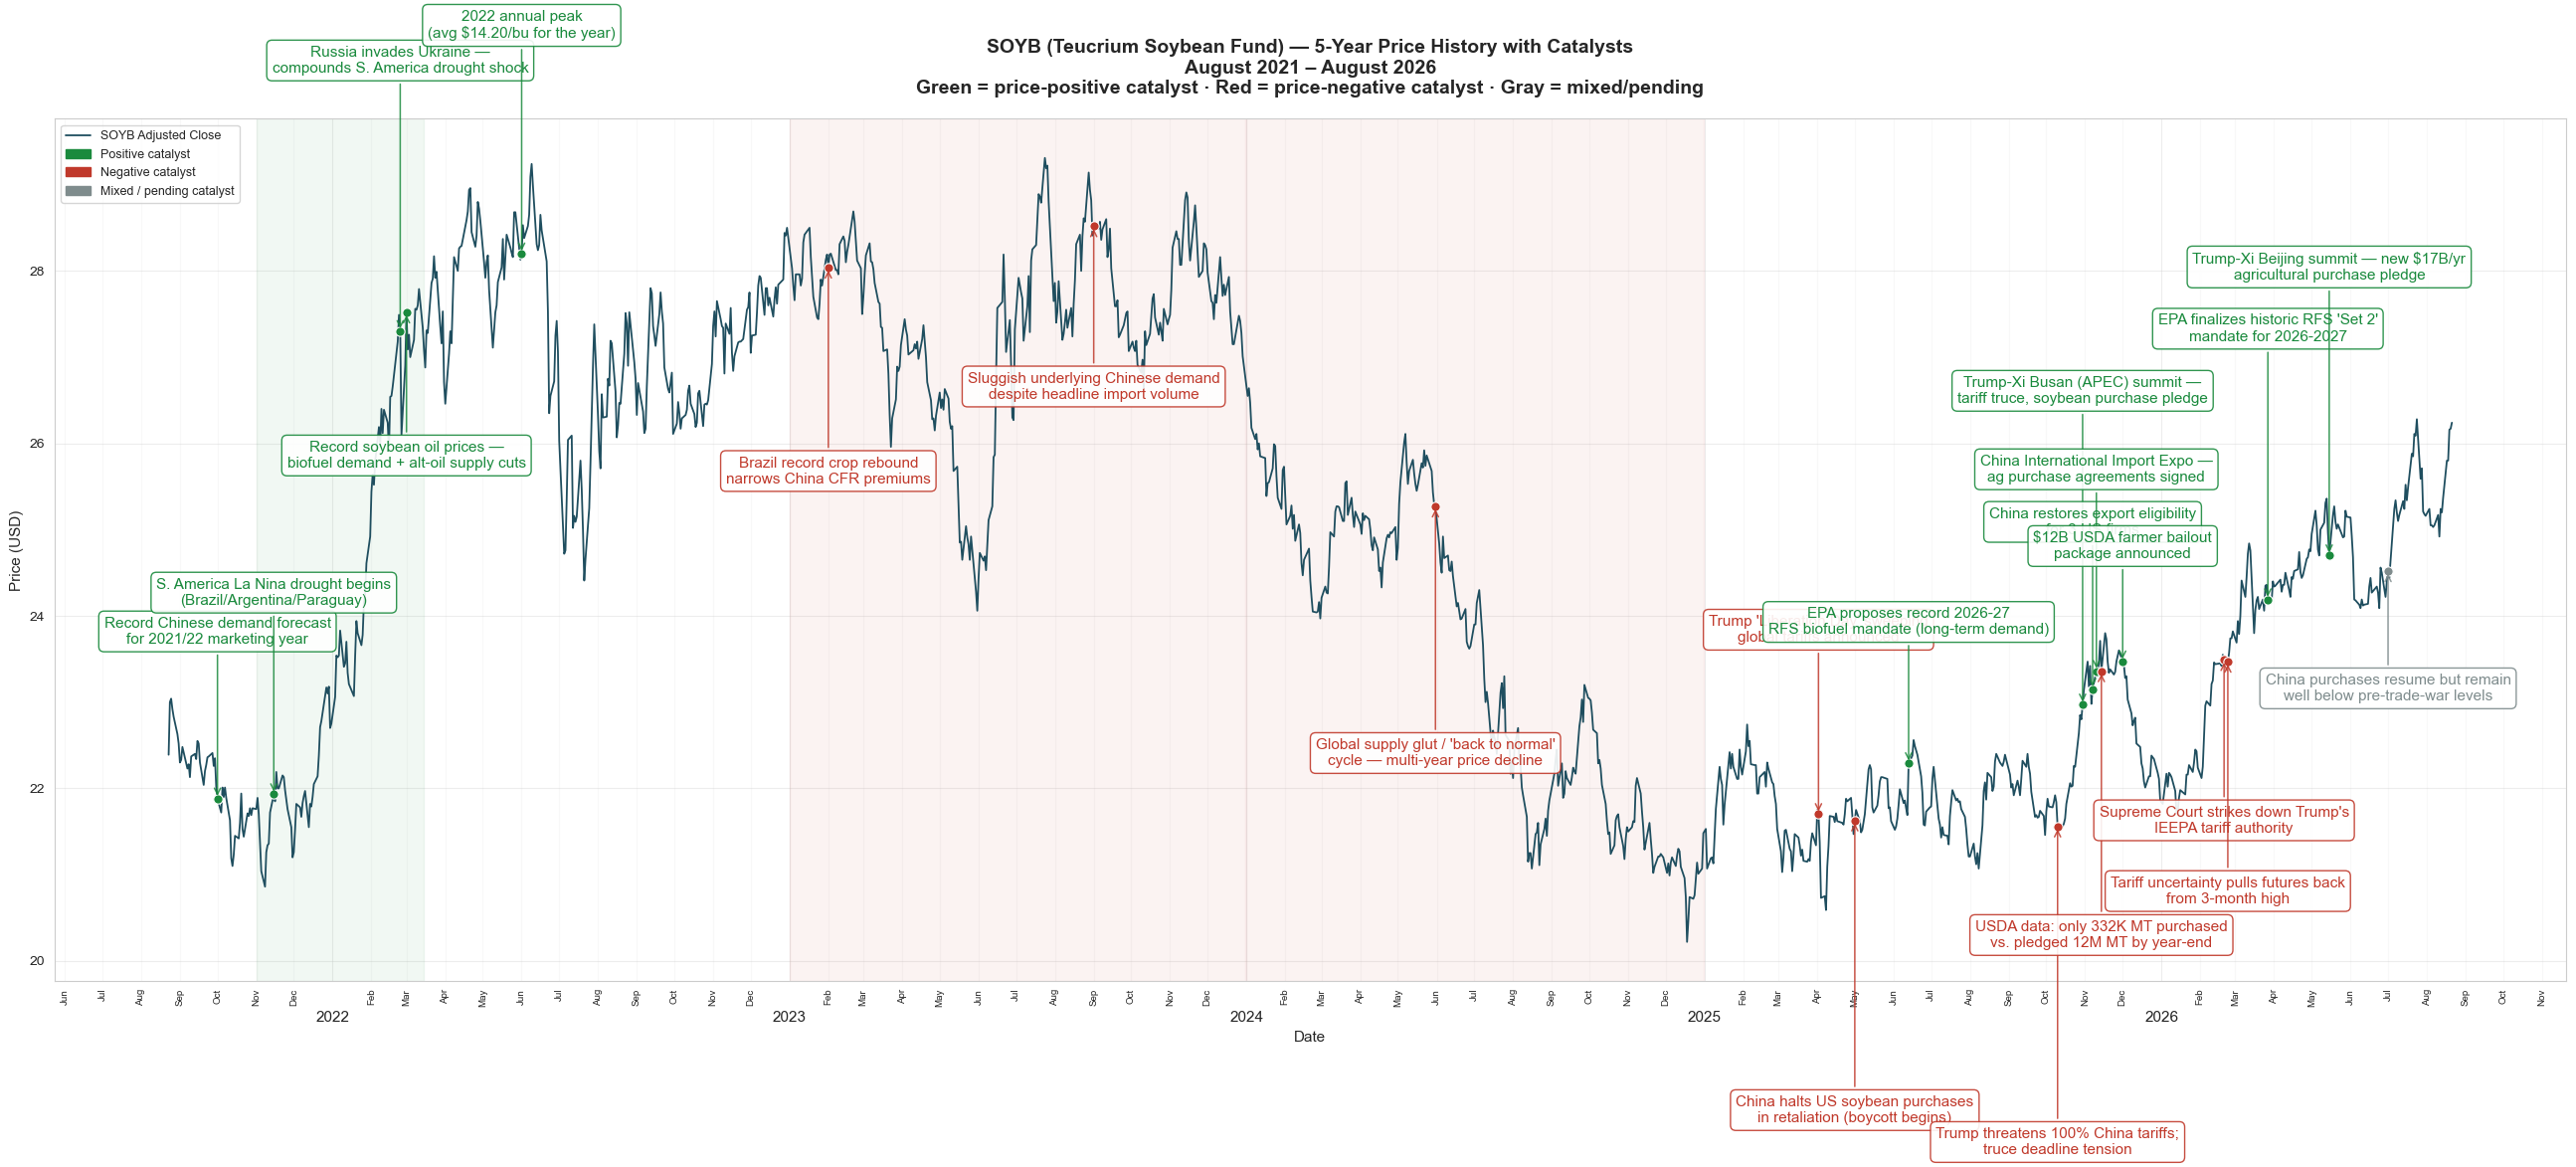

Data range: 2021-08-23 to 2026-08-21
Price range: $20.22 - $29.31
Total catalysts plotted: 22


In [3]:
"""
SOYB (Teucrium Soybean Fund) — 5-Year Retrospective Catalyst Chart
====================================================================
Fetches 5 years of daily adjusted-close price data for SOYB via yfinance
and plots it with annotated callouts marking the major macro / geopolitical
/ climate catalysts researched for the period (2021-2026).

Color coding:
    GREEN = catalyst that was price-positive for soybeans / SOYB
    RED   = catalyst that was price-negative for soybeans / SOYB
    GRAY  = mixed / uncertain / pending catalyst (direction not yet resolved)

Requirements:
    pip install yfinance matplotlib seaborn pandas

Note: Not executed in this environment (no network access here) —
run locally and adjust annotation y-offsets once you see the real
price scale returned by yfinance.
"""

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns

# ----------------------------------------------------------------------
# 1. Fetch data
# ----------------------------------------------------------------------
TICKER = "SOYB"
PERIOD_YEARS = 5

df = yf.download(TICKER, period=f"{PERIOD_YEARS}y", interval="1d", auto_adjust=True)
df = df.dropna()

if df.empty:
    raise RuntimeError(
        f"No data returned for {TICKER}. Check ticker validity and network connection."
    )

# Flatten MultiIndex columns if yfinance returns them (common with single-ticker downloads)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

price_col = "Close"  # auto_adjust=True makes 'Close' the adjusted close

# ----------------------------------------------------------------------
# 2. Define catalyst annotations
# ----------------------------------------------------------------------
# Each entry: (date_str, label, vertical_offset_in_price_units, direction, shaded_span_or_None)
# direction: "positive" -> green, "negative" -> red, "neutral" -> gray
DIRECTION_COLORS = {
    "positive": "#1a8a3d",   # green
    "negative": "#c0392b",   # red
    "neutral":  "#7f8c8d",   # gray
}

catalysts = [
    # --- 2021 ---
    ("2021-10-01", "Record Chinese demand forecast\nfor 2021/22 marketing year",
     1.8, "positive", None),

    # --- Late 2021 - early 2022: La Nina drought + Ukraine war ---
    ("2021-11-15", "S. America La Nina drought begins\n(Brazil/Argentina/Paraguay)",
     2.2, "positive", ("2021-11-01", "2022-03-15")),
    ("2022-02-24", "Russia invades Ukraine —\ncompounds S. America drought shock",
     3.0, "positive", None),
    ("2022-06-01", "2022 annual peak\n(avg $14.20/bu for the year)",
     2.5, "positive", None),

    # --- 2021-22: biofuel / soy oil ---
    ("2022-03-01", "Record soybean oil prices —\nbiofuel demand + alt-oil supply cuts",
     -1.8, "positive", None),

    # --- 2023: Brazil rebound, weakening demand ---
    ("2023-02-01", "Brazil record crop rebound\nnarrows China CFR premiums",
     -2.5, "negative", ("2023-01-01", "2023-12-31")),
    ("2023-09-01", "Sluggish underlying Chinese demand\ndespite headline import volume",
     -2.0, "negative", None),

    # --- 2024: supply glut ---
    ("2024-06-01", "Global supply glut / 'back to normal'\ncycle — multi-year price decline",
     -3.0, "negative", ("2024-01-01", "2024-12-31")),

    # --- 2025: tariff war ---
    ("2025-04-02", "Trump 'Liberation Day' sweeping\nglobal tariffs announced",
     2.0, "negative", None),
    ("2025-05-01", "China halts US soybean purchases\nin retaliation (boycott begins)",
     -3.5, "negative", None),
    ("2025-06-13", "EPA proposes record 2026-27\nRFS biofuel mandate (long-term demand)",
     1.5, "positive", None),
    ("2025-10-10", "Trump threatens 100% China tariffs;\ntruce deadline tension",
     -3.8, "negative", None),
    ("2025-10-30", "Trump-Xi Busan (APEC) summit —\ntariff truce, soybean purchase pledge",
     3.5, "positive", None),
    ("2025-11-07", "China restores export eligibility\nfor 3 US firms",
     1.8, "positive", None),
    ("2025-11-10", "China International Import Expo —\nag purchase agreements signed",
     2.2, "positive", None),
    ("2025-11-14", "USDA data: only 332K MT purchased\nvs. pledged 12M MT by year-end",
     -3.2, "negative", None),
    ("2025-12-01", "$12B USDA farmer bailout\npackage announced",
     1.2, "positive", None),

    # --- 2026 ---
    ("2026-02-20", "Supreme Court strikes down Trump's\nIEEPA tariff authority",
     -2.0, "negative", None),
    ("2026-02-23", "Tariff uncertainty pulls futures back\nfrom 3-month high",
     -2.8, "negative", None),
    ("2026-03-27", "EPA finalizes historic RFS 'Set 2'\nmandate for 2026-2027",
     3.0, "positive", None),
    ("2026-05-15", "Trump-Xi Beijing summit — new $17B/yr\nagricultural purchase pledge",
     3.2, "positive", None),
    ("2026-07-01", "China purchases resume but remain\nwell below pre-trade-war levels",
     -1.5, "neutral", None),
    ("2026-09-24", "Xi Jinping state visit — Trump meeting\n(pending, inside competition window)",
     2.5, "neutral", None),
]

# ----------------------------------------------------------------------
# 3. Plot
# ----------------------------------------------------------------------
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(26, 12))

ax.plot(df.index, df[price_col], color="#1f4e5f", linewidth=1.3, label=f"{TICKER} Adjusted Close", zorder=3)

for date_str, label, offset, direction, span in catalysts:
    date = pd.Timestamp(date_str)
    if date < df.index.min() or date > df.index.max():
        continue  # skip catalysts outside the fetched window

    color = DIRECTION_COLORS[direction]

    # Find nearest actual trading-day price for the marker
    nearest_idx = df.index.get_indexer([date], method="nearest")[0]
    nearest_date = df.index[nearest_idx]
    nearest_price = df[price_col].iloc[nearest_idx]

    # Marker dot
    ax.scatter(nearest_date, nearest_price, color=color, s=45, zorder=5, edgecolor="white", linewidth=0.8)

    # Annotation with arrow
    text_y = nearest_price + offset
    ax.annotate(
        label,
        xy=(nearest_date, nearest_price),
        xytext=(nearest_date, text_y),
        fontsize=11,
        fontweight="medium",
        ha="center",
        color=color,
        arrowprops=dict(arrowstyle="->", color=color, lw=1.1, alpha=0.85),
        bbox=dict(boxstyle="round,pad=0.35", fc="white", ec=color, alpha=0.9),
        zorder=6,
    )

    # Optional shaded span (e.g. a multi-month drought/glut period)
    if span is not None:
        start, end = pd.Timestamp(span[0]), pd.Timestamp(span[1])
        ax.axvspan(start, end, color=color, alpha=0.06, zorder=1)

# ----------------------------------------------------------------------
# 4. Formatting
# ----------------------------------------------------------------------
span_start = df.index.min().strftime("%B %Y")
span_end = df.index.max().strftime("%B %Y")

ax.set_title(
    f"{TICKER} (Teucrium Soybean Fund) — 5-Year Price History with Catalysts\n"
    f"{span_start} – {span_end}\n"
    "Green = price-positive catalyst · Red = price-negative catalyst · Gray = mixed/pending",
    fontsize=14, fontweight="bold", pad=18,
)
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Price (USD)", fontsize=11)

# Major ticks = years, minor ticks = months, both labeled
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_minor_formatter(mdates.DateFormatter("%b"))

ax.tick_params(axis="x", which="minor", labelsize=7, rotation=90)
ax.tick_params(axis="x", which="major", labelsize=11, pad=18)

# Custom legend: price line + direction color key
price_handle = plt.Line2D([0], [0], color="#1f4e5f", lw=1.3, label=f"{TICKER} Adjusted Close")
pos_patch = mpatches.Patch(color=DIRECTION_COLORS["positive"], label="Positive catalyst")
neg_patch = mpatches.Patch(color=DIRECTION_COLORS["negative"], label="Negative catalyst")
neu_patch = mpatches.Patch(color=DIRECTION_COLORS["neutral"], label="Mixed / pending catalyst")
ax.legend(handles=[price_handle, pos_patch, neg_patch, neu_patch], loc="upper left", fontsize=9)

ax.grid(True, which="major", axis="both", alpha=0.35)
ax.grid(True, which="minor", axis="x", alpha=0.12)

plt.tight_layout()
plt.savefig("soyb_5yr_catalyst_chart.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Data range: {df.index.min().date()} to {df.index.max().date()}")
print(f"Price range: ${df[price_col].min():.2f} - ${df[price_col].max():.2f}")
print(f"Total catalysts plotted: {sum(1 for c in catalysts if df.index.min() <= pd.Timestamp(c[0]) <= df.index.max())}")

[*********************100%***********************]  1 of 1 completed
Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


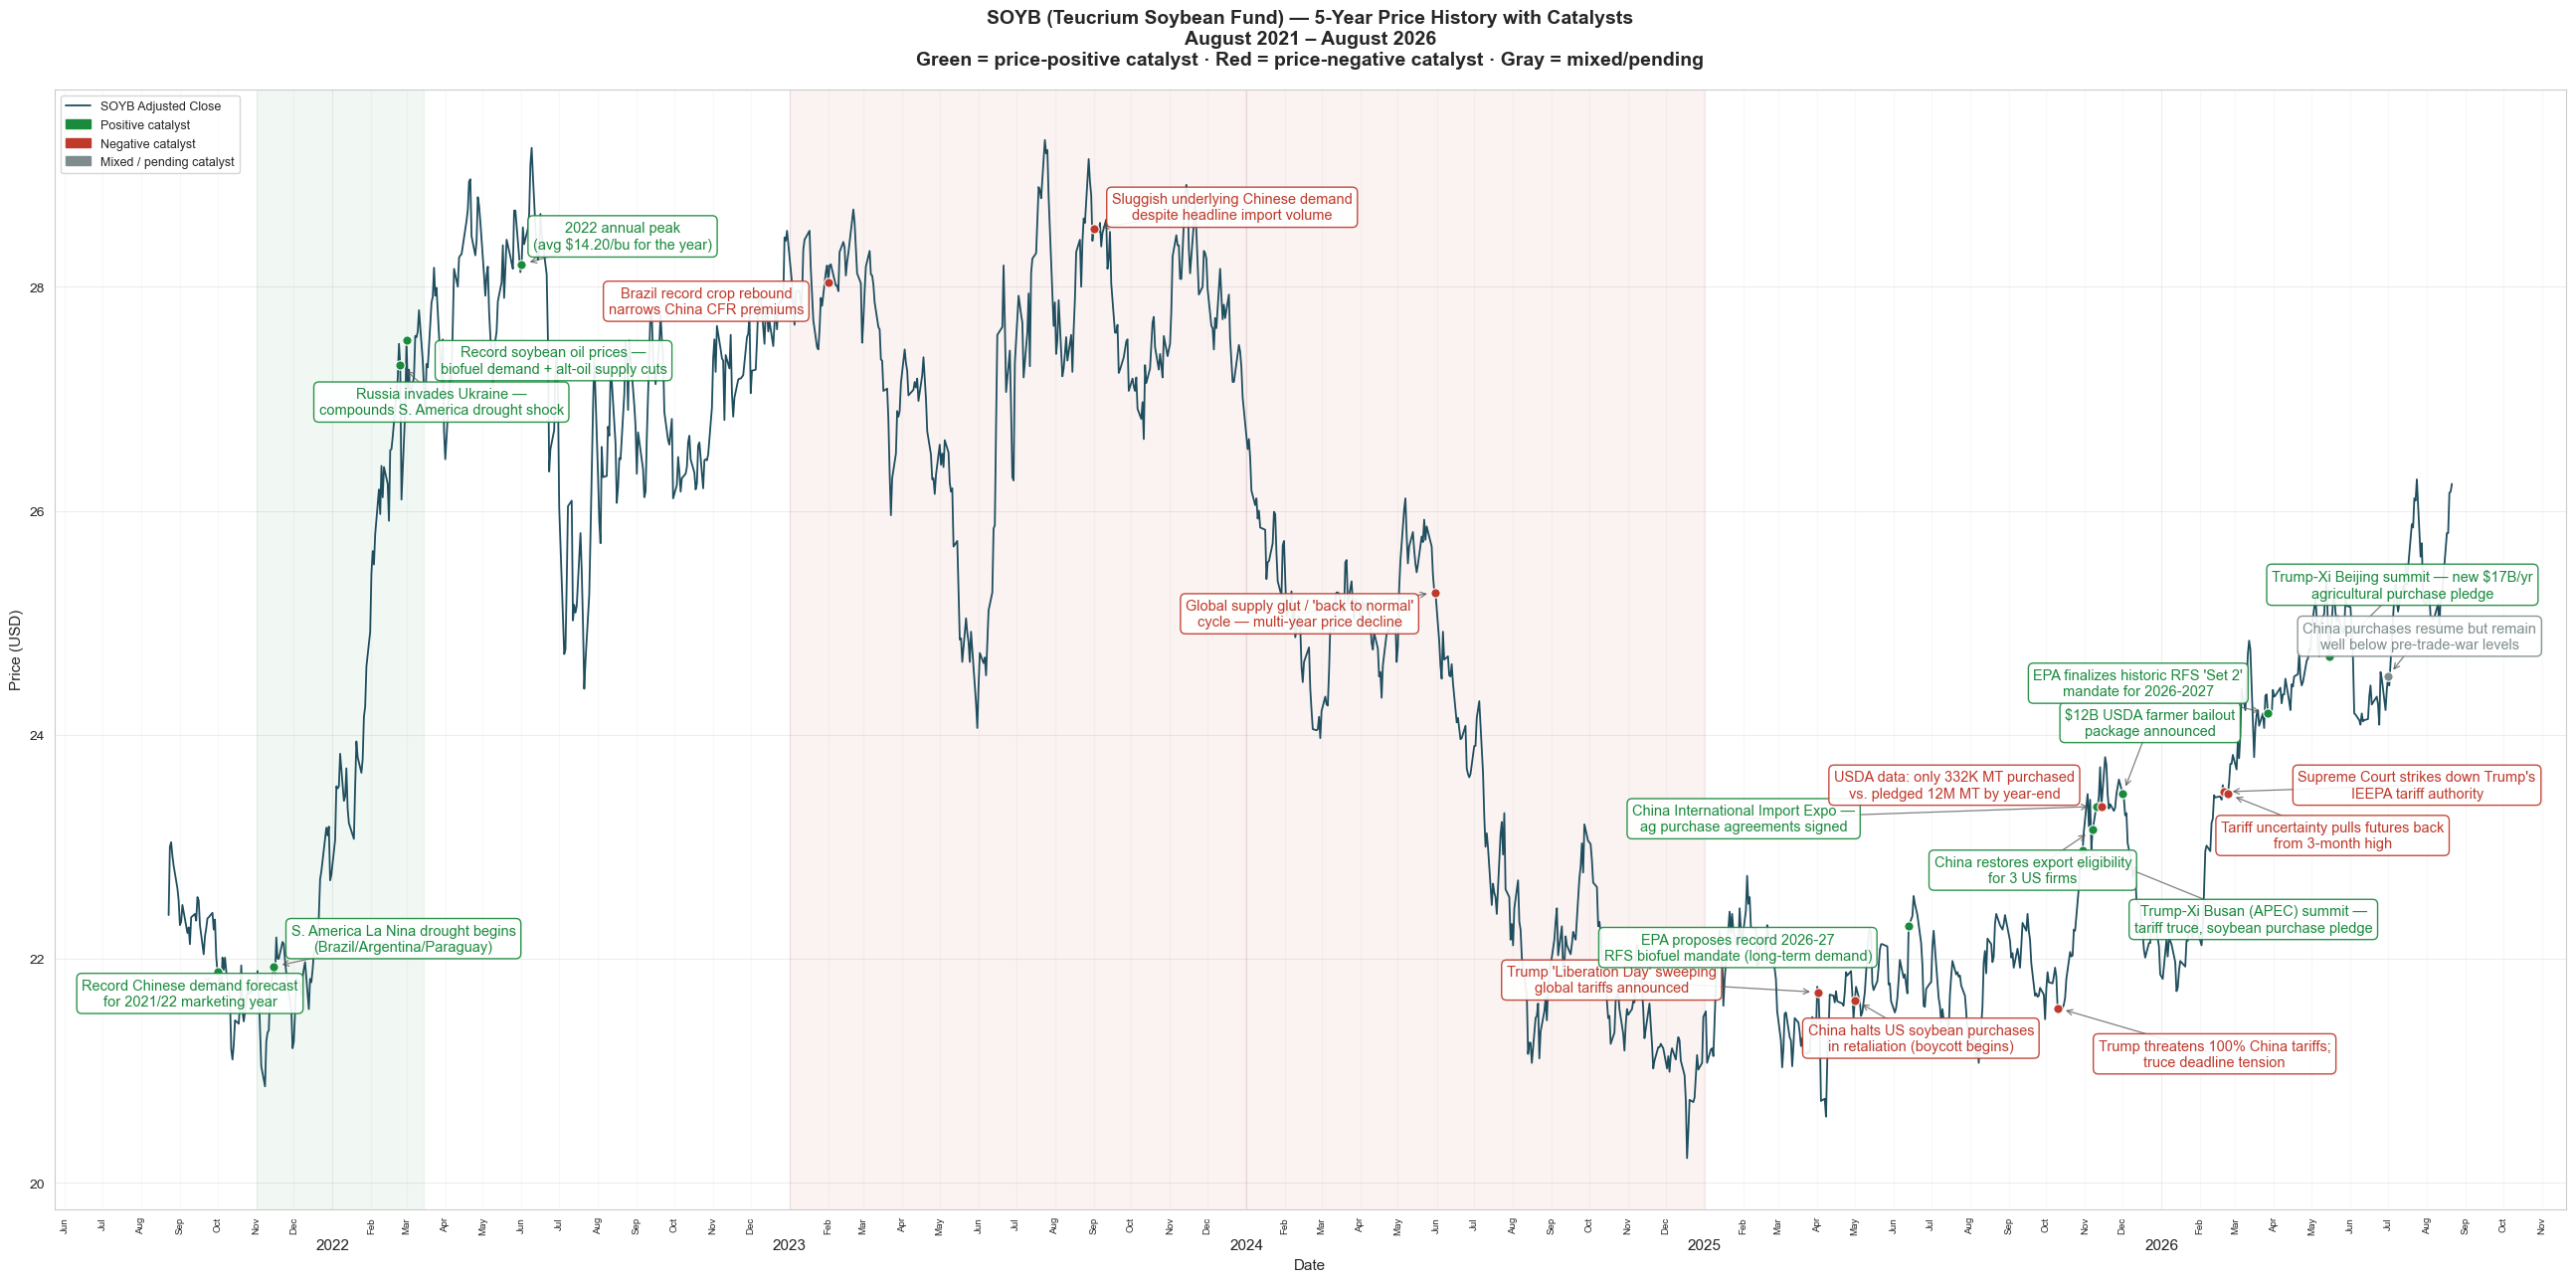

Data range: 2021-08-23 to 2026-08-21
Price range: $20.22 - $29.31
Total catalysts plotted: 22


In [6]:
"""
SOYB (Teucrium Soybean Fund) — 5-Year Retrospective Catalyst Chart
====================================================================
Fetches 5 years of daily adjusted-close price data for SOYB via yfinance
and plots it with annotated callouts marking the major macro / geopolitical
/ climate catalysts researched for the period (2021-2026).

Color coding:
    GREEN = catalyst that was price-positive for soybeans / SOYB
    RED   = catalyst that was price-negative for soybeans / SOYB
    GRAY  = mixed / uncertain / pending catalyst (direction not yet resolved)

Overlap handling:
    Annotation labels are placed with the `adjustText` library, which
    automatically repels text boxes away from each other and from the
    data points, then draws a connector line from each label back to
    its correct point on the price line. This is what keeps dense
    clusters of catalysts (e.g. Oct-Dec 2025) from overlapping.

Requirements:
    pip install yfinance matplotlib seaborn pandas adjustText

Note: Not executed in this environment (no network access here) —
run locally and re-check spacing once you see the real price scale
and label layout adjustText settles on.
"""

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns

try:
    from adjustText import adjust_text
except ImportError as e:
    raise ImportError(
        "This script requires the 'adjustText' package to prevent label "
        "overlap. Install it with: pip install adjustText"
    ) from e

# ----------------------------------------------------------------------
# 1. Fetch data
# ----------------------------------------------------------------------
TICKER = "SOYB"
PERIOD_YEARS = 5

df = yf.download(TICKER, period=f"{PERIOD_YEARS}y", interval="1d", auto_adjust=True)
df = df.dropna()

if df.empty:
    raise RuntimeError(
        f"No data returned for {TICKER}. Check ticker validity and network connection."
    )

# Flatten MultiIndex columns if yfinance returns them (common with single-ticker downloads)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

price_col = "Close"  # auto_adjust=True makes 'Close' the adjusted close

# ----------------------------------------------------------------------
# 2. Define catalyst annotations
# ----------------------------------------------------------------------
# Each entry: (date_str, label, direction, shaded_span_or_None)
# direction: "positive" -> green, "negative" -> red, "neutral" -> gray
# (No manual y-offset needed anymore — adjustText positions labels automatically.)
DIRECTION_COLORS = {
    "positive": "#1a8a3d",   # green
    "negative": "#c0392b",   # red
    "neutral":  "#7f8c8d",   # gray
}

catalysts = [
    # --- 2021 ---
    ("2021-10-01", "Record Chinese demand forecast\nfor 2021/22 marketing year",
     "positive", None),

    # --- Late 2021 - early 2022: La Nina drought + Ukraine war ---
    ("2021-11-15", "S. America La Nina drought begins\n(Brazil/Argentina/Paraguay)",
     "positive", ("2021-11-01", "2022-03-15")),
    ("2022-02-24", "Russia invades Ukraine —\ncompounds S. America drought shock",
     "positive", None),
    ("2022-06-01", "2022 annual peak\n(avg $14.20/bu for the year)",
     "positive", None),

    # --- 2021-22: biofuel / soy oil ---
    ("2022-03-01", "Record soybean oil prices —\nbiofuel demand + alt-oil supply cuts",
     "positive", None),

    # --- 2023: Brazil rebound, weakening demand ---
    ("2023-02-01", "Brazil record crop rebound\nnarrows China CFR premiums",
     "negative", ("2023-01-01", "2023-12-31")),
    ("2023-09-01", "Sluggish underlying Chinese demand\ndespite headline import volume",
     "negative", None),

    # --- 2024: supply glut ---
    ("2024-06-01", "Global supply glut / 'back to normal'\ncycle — multi-year price decline",
     "negative", ("2024-01-01", "2024-12-31")),

    # --- 2025: tariff war ---
    ("2025-04-02", "Trump 'Liberation Day' sweeping\nglobal tariffs announced",
     "negative", None),
    ("2025-05-01", "China halts US soybean purchases\nin retaliation (boycott begins)",
     "negative", None),
    ("2025-06-13", "EPA proposes record 2026-27\nRFS biofuel mandate (long-term demand)",
     "positive", None),
    ("2025-10-10", "Trump threatens 100% China tariffs;\ntruce deadline tension",
     "negative", None),
    ("2025-10-30", "Trump-Xi Busan (APEC) summit —\ntariff truce, soybean purchase pledge",
     "positive", None),
    ("2025-11-07", "China restores export eligibility\nfor 3 US firms",
     "positive", None),
    ("2025-11-10", "China International Import Expo —\nag purchase agreements signed",
     "positive", None),
    ("2025-11-14", "USDA data: only 332K MT purchased\nvs. pledged 12M MT by year-end",
     "negative", None),
    ("2025-12-01", "$12B USDA farmer bailout\npackage announced",
     "positive", None),

    # --- 2026 ---
    ("2026-02-20", "Supreme Court strikes down Trump's\nIEEPA tariff authority",
     "negative", None),
    ("2026-02-23", "Tariff uncertainty pulls futures back\nfrom 3-month high",
     "negative", None),
    ("2026-03-27", "EPA finalizes historic RFS 'Set 2'\nmandate for 2026-2027",
     "positive", None),
    ("2026-05-15", "Trump-Xi Beijing summit — new $17B/yr\nagricultural purchase pledge",
     "positive", None),
    ("2026-07-01", "China purchases resume but remain\nwell below pre-trade-war levels",
     "neutral", None),
    ("2026-09-24", "Xi Jinping state visit — Trump meeting\n(pending, inside competition window)",
     "neutral", None),
]

# ----------------------------------------------------------------------
# 3. Plot
# ----------------------------------------------------------------------
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(26, 13))

ax.plot(df.index, df[price_col], color="#1f4e5f", linewidth=1.3, label=f"{TICKER} Adjusted Close", zorder=3)

text_objects = []
point_x_num = []
point_y = []

for date_str, label, direction, span in catalysts:
    date = pd.Timestamp(date_str)
    if date < df.index.min() or date > df.index.max():
        continue  # skip catalysts outside the fetched window

    color = DIRECTION_COLORS[direction]

    # Find nearest actual trading-day price for the marker
    nearest_idx = df.index.get_indexer([date], method="nearest")[0]
    nearest_date = df.index[nearest_idx]
    nearest_price = df[price_col].iloc[nearest_idx]
    x_num = mdates.date2num(nearest_date)

    # Marker dot at the true data point
    ax.scatter(nearest_date, nearest_price, color=color, s=45, zorder=5, edgecolor="white", linewidth=0.8)

    # Place text at a small initial offset near its point; adjustText will
    # move it to a clear spot and draw a connector back to (x_num, nearest_price)
    t = ax.text(
        x_num, nearest_price, label,
        fontsize=10.5, fontweight="medium", ha="center", va="center",
        color=color,
        bbox=dict(boxstyle="round,pad=0.35", fc="white", ec=color, alpha=0.92),
        zorder=6,
    )
    text_objects.append(t)
    point_x_num.append(x_num)
    point_y.append(nearest_price)

    # Optional shaded span (e.g. a multi-month drought/glut period)
    if span is not None:
        start, end = pd.Timestamp(span[0]), pd.Timestamp(span[1])
        ax.axvspan(start, end, color=color, alpha=0.06, zorder=1)

# Automatically resolve overlaps: repel labels from each other and from the
# price line's data points, then draw a connector line from each label back
# to its true point.
adjust_text(
    text_objects,
    x=point_x_num,
    y=point_y,
    ax=ax,
    expand_text=(1.15, 1.35),
    expand_points=(1.6, 1.8),
    force_text=(0.6, 1.1),
    force_points=(0.4, 0.6),
    arrowprops=dict(arrowstyle="->", color="#555555", lw=0.9, alpha=0.75, shrinkA=2, shrinkB=6),
)

# ----------------------------------------------------------------------
# 4. Formatting
# ----------------------------------------------------------------------
span_start = df.index.min().strftime("%B %Y")
span_end = df.index.max().strftime("%B %Y")

ax.set_title(
    f"{TICKER} (Teucrium Soybean Fund) — 5-Year Price History with Catalysts\n"
    f"{span_start} – {span_end}\n"
    "Green = price-positive catalyst · Red = price-negative catalyst · Gray = mixed/pending",
    fontsize=14, fontweight="bold", pad=18,
)
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Price (USD)", fontsize=11)

# Major ticks = years, minor ticks = months, both labeled
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_minor_formatter(mdates.DateFormatter("%b"))

ax.tick_params(axis="x", which="minor", labelsize=7, rotation=90)
ax.tick_params(axis="x", which="major", labelsize=11, pad=18)

# Custom legend: price line + direction color key
price_handle = plt.Line2D([0], [0], color="#1f4e5f", lw=1.3, label=f"{TICKER} Adjusted Close")
pos_patch = mpatches.Patch(color=DIRECTION_COLORS["positive"], label="Positive catalyst")
neg_patch = mpatches.Patch(color=DIRECTION_COLORS["negative"], label="Negative catalyst")
neu_patch = mpatches.Patch(color=DIRECTION_COLORS["neutral"], label="Mixed / pending catalyst")
ax.legend(handles=[price_handle, pos_patch, neg_patch, neu_patch], loc="upper left", fontsize=9)

ax.grid(True, which="major", axis="both", alpha=0.35)
ax.grid(True, which="minor", axis="x", alpha=0.12)

plt.tight_layout()
plt.savefig("soyb_5yr_catalyst_chart.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Data range: {df.index.min().date()} to {df.index.max().date()}")
print(f"Price range: ${df[price_col].min():.2f} - ${df[price_col].max():.2f}")
print(f"Total catalysts plotted: {len(text_objects)}")

In [5]:
pip install adjustText

Note: you may need to restart the kernel to use updated packages.


[*********************100%***********************]  1 of 1 completed


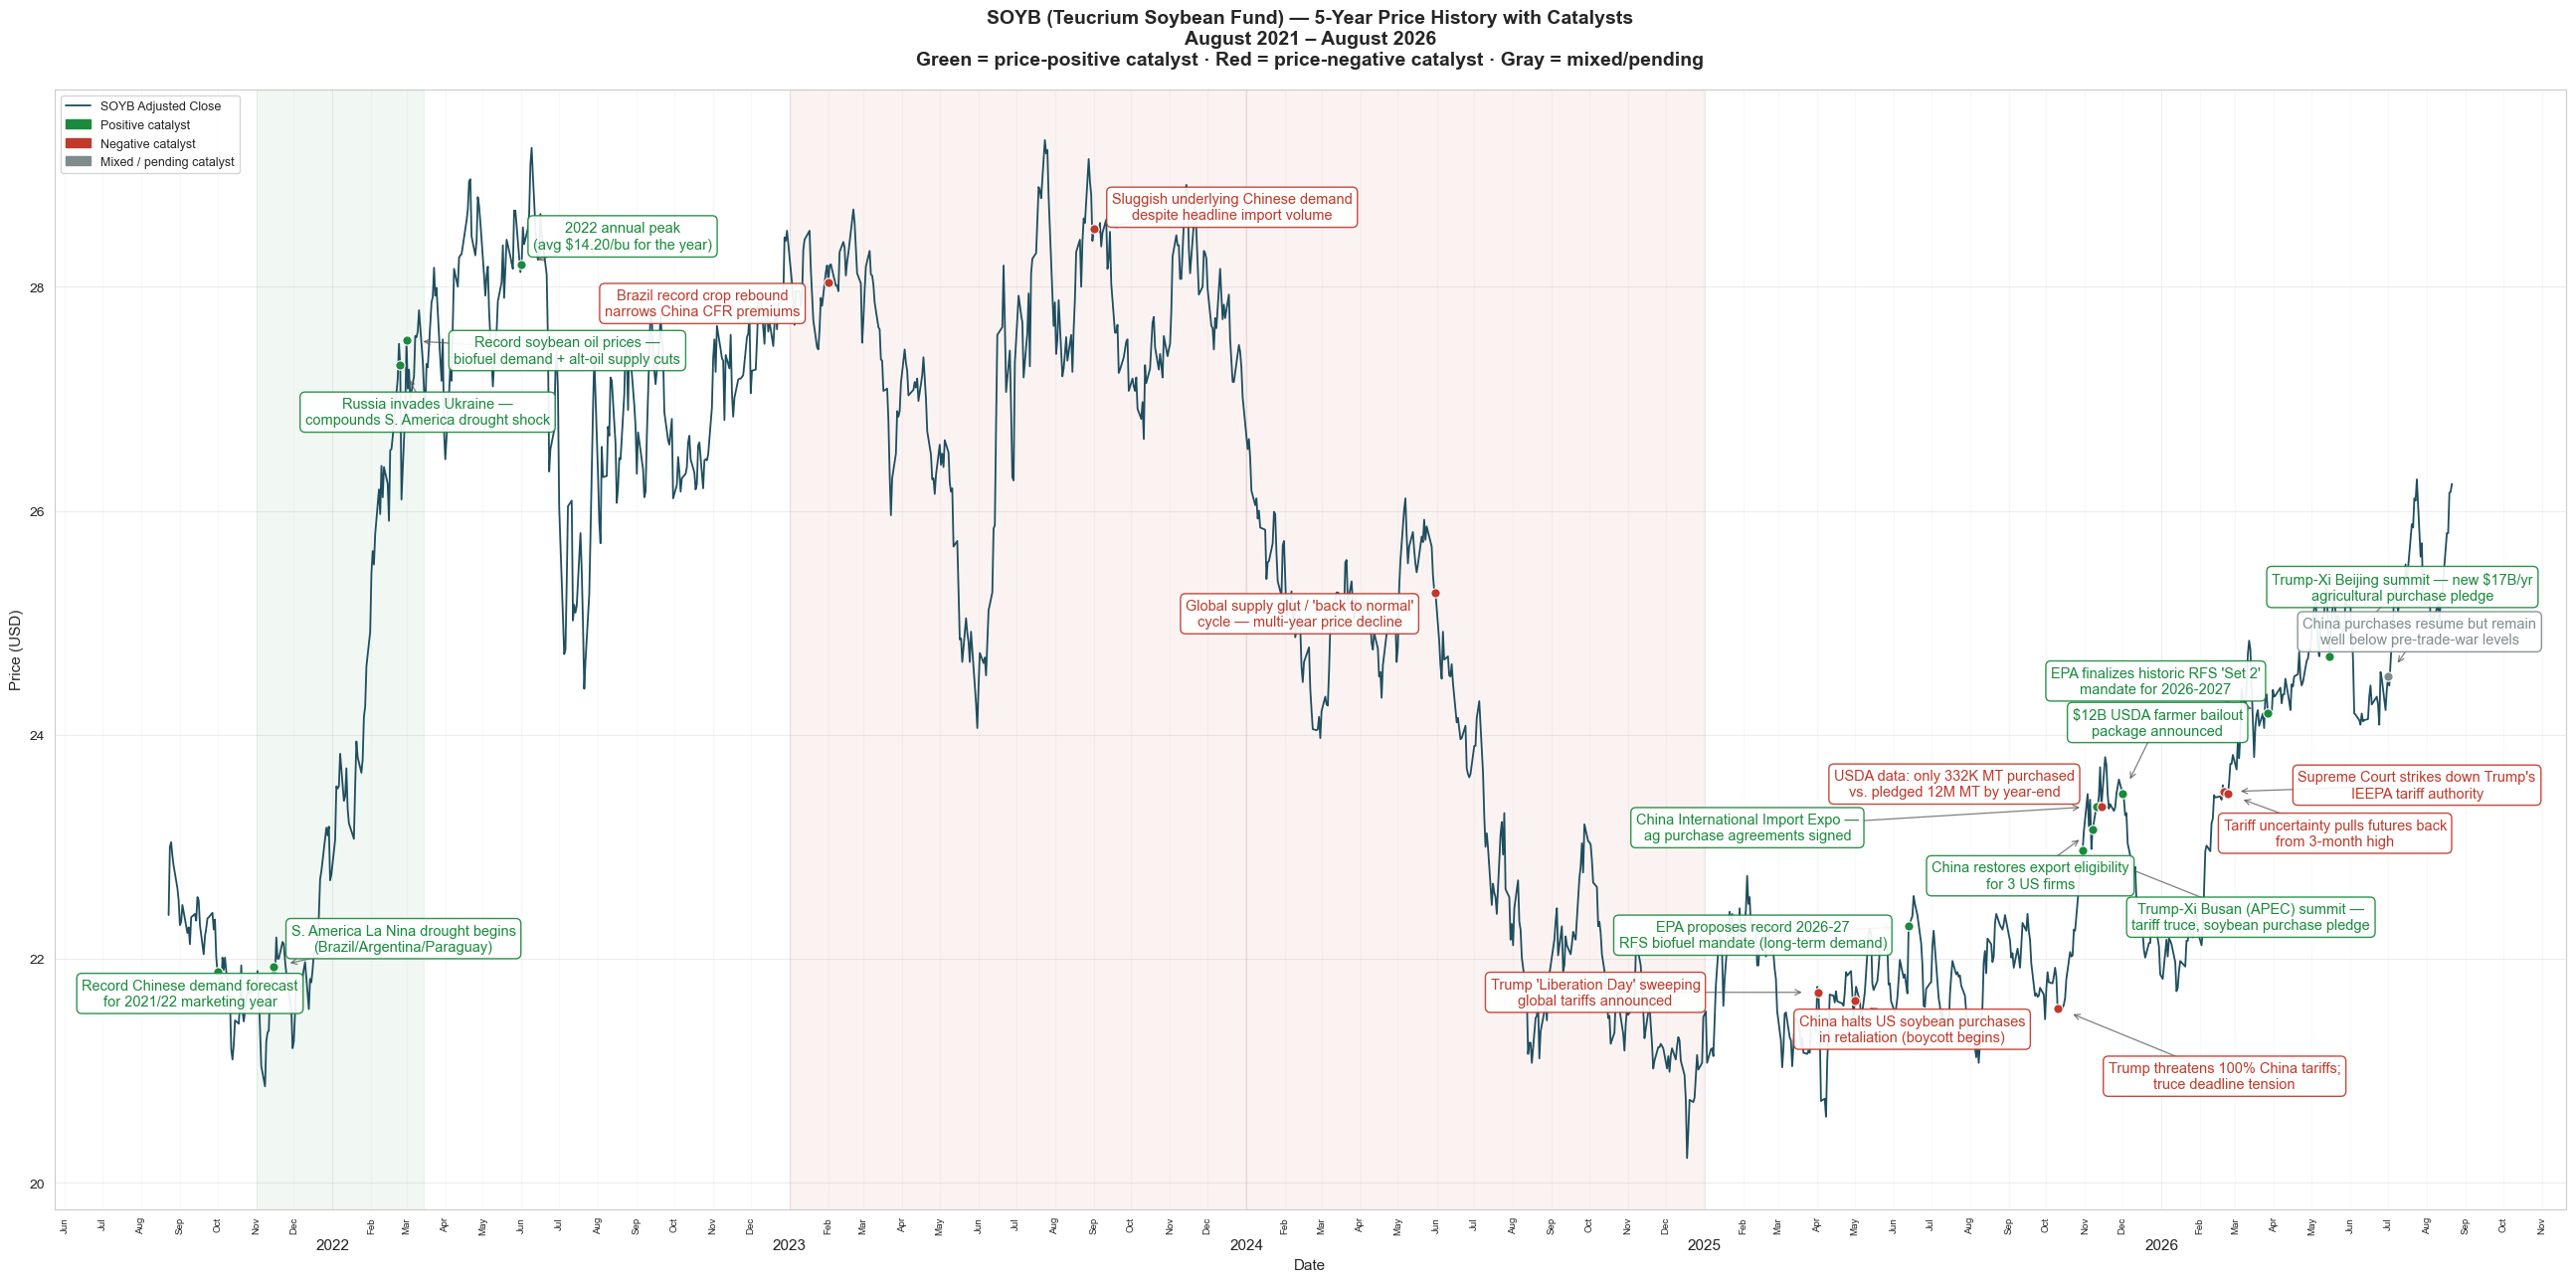

Data range: 2021-08-23 to 2026-08-21
Price range: $20.22 - $29.31
Total catalysts plotted: 22


In [7]:
"""
SOYB (Teucrium Soybean Fund) — 5-Year Retrospective Catalyst Chart
====================================================================
Fetches 5 years of daily adjusted-close price data for SOYB via yfinance
and plots it with annotated callouts marking the major macro / geopolitical
/ climate catalysts researched for the period (2021-2026).

Color coding:
    GREEN = catalyst that was price-positive for soybeans / SOYB
    RED   = catalyst that was price-negative for soybeans / SOYB
    GRAY  = mixed / uncertain / pending catalyst (direction not yet resolved)

Overlap handling:
    Annotation labels are placed with the `adjustText` library, which
    automatically repels text boxes away from each other and from the
    data points, then draws a connector line from each label back to
    its correct point on the price line. This is what keeps dense
    clusters of catalysts (e.g. Oct-Dec 2025) from overlapping.

Requirements:
    pip install yfinance matplotlib seaborn pandas adjustText

Note: Not executed in this environment (no network access here) —
run locally and re-check spacing once you see the real price scale
and label layout adjustText settles on.
"""

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns

try:
    from adjustText import adjust_text
except ImportError as e:
    raise ImportError(
        "This script requires the 'adjustText' package to prevent label "
        "overlap. Install it with: pip install adjustText"
    ) from e

# ----------------------------------------------------------------------
# 1. Fetch data
# ----------------------------------------------------------------------
TICKER = "SOYB"
PERIOD_YEARS = 5

df = yf.download(TICKER, period=f"{PERIOD_YEARS}y", interval="1d", auto_adjust=True)
df = df.dropna()

if df.empty:
    raise RuntimeError(
        f"No data returned for {TICKER}. Check ticker validity and network connection."
    )

# Flatten MultiIndex columns if yfinance returns them (common with single-ticker downloads)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

price_col = "Close"  # auto_adjust=True makes 'Close' the adjusted close

# ----------------------------------------------------------------------
# 2. Define catalyst annotations
# ----------------------------------------------------------------------
# Each entry: (date_str, label, direction, shaded_span_or_None)
# direction: "positive" -> green, "negative" -> red, "neutral" -> gray
# (No manual y-offset needed anymore — adjustText positions labels automatically.)
DIRECTION_COLORS = {
    "positive": "#1a8a3d",   # green
    "negative": "#c0392b",   # red
    "neutral":  "#7f8c8d",   # gray
}

catalysts = [
    # --- 2021 ---
    ("2021-10-01", "Record Chinese demand forecast\nfor 2021/22 marketing year",
     "positive", None),

    # --- Late 2021 - early 2022: La Nina drought + Ukraine war ---
    ("2021-11-15", "S. America La Nina drought begins\n(Brazil/Argentina/Paraguay)",
     "positive", ("2021-11-01", "2022-03-15")),
    ("2022-02-24", "Russia invades Ukraine —\ncompounds S. America drought shock",
     "positive", None),
    ("2022-06-01", "2022 annual peak\n(avg $14.20/bu for the year)",
     "positive", None),

    # --- 2021-22: biofuel / soy oil ---
    ("2022-03-01", "Record soybean oil prices —\nbiofuel demand + alt-oil supply cuts",
     "positive", None),

    # --- 2023: Brazil rebound, weakening demand ---
    ("2023-02-01", "Brazil record crop rebound\nnarrows China CFR premiums",
     "negative", ("2023-01-01", "2023-12-31")),
    ("2023-09-01", "Sluggish underlying Chinese demand\ndespite headline import volume",
     "negative", None),

    # --- 2024: supply glut ---
    ("2024-06-01", "Global supply glut / 'back to normal'\ncycle — multi-year price decline",
     "negative", ("2024-01-01", "2024-12-31")),

    # --- 2025: tariff war ---
    ("2025-04-02", "Trump 'Liberation Day' sweeping\nglobal tariffs announced",
     "negative", None),
    ("2025-05-01", "China halts US soybean purchases\nin retaliation (boycott begins)",
     "negative", None),
    ("2025-06-13", "EPA proposes record 2026-27\nRFS biofuel mandate (long-term demand)",
     "positive", None),
    ("2025-10-10", "Trump threatens 100% China tariffs;\ntruce deadline tension",
     "negative", None),
    ("2025-10-30", "Trump-Xi Busan (APEC) summit —\ntariff truce, soybean purchase pledge",
     "positive", None),
    ("2025-11-07", "China restores export eligibility\nfor 3 US firms",
     "positive", None),
    ("2025-11-10", "China International Import Expo —\nag purchase agreements signed",
     "positive", None),
    ("2025-11-14", "USDA data: only 332K MT purchased\nvs. pledged 12M MT by year-end",
     "negative", None),
    ("2025-12-01", "$12B USDA farmer bailout\npackage announced",
     "positive", None),

    # --- 2026 ---
    ("2026-02-20", "Supreme Court strikes down Trump's\nIEEPA tariff authority",
     "negative", None),
    ("2026-02-23", "Tariff uncertainty pulls futures back\nfrom 3-month high",
     "negative", None),
    ("2026-03-27", "EPA finalizes historic RFS 'Set 2'\nmandate for 2026-2027",
     "positive", None),
    ("2026-05-15", "Trump-Xi Beijing summit — new $17B/yr\nagricultural purchase pledge",
     "positive", None),
    ("2026-07-01", "China purchases resume but remain\nwell below pre-trade-war levels",
     "neutral", None),
    ("2026-09-24", "Xi Jinping state visit — Trump meeting\n(pending, inside competition window)",
     "neutral", None),
]

# ----------------------------------------------------------------------
# 3. Plot
# ----------------------------------------------------------------------
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(26, 13))

ax.plot(df.index, df[price_col], color="#1f4e5f", linewidth=1.3, label=f"{TICKER} Adjusted Close", zorder=3)

text_objects = []
point_x_num = []
point_y = []

for date_str, label, direction, span in catalysts:
    date = pd.Timestamp(date_str)
    if date < df.index.min() or date > df.index.max():
        continue  # skip catalysts outside the fetched window

    color = DIRECTION_COLORS[direction]

    # Find nearest actual trading-day price for the marker
    nearest_idx = df.index.get_indexer([date], method="nearest")[0]
    nearest_date = df.index[nearest_idx]
    nearest_price = df[price_col].iloc[nearest_idx]
    x_num = mdates.date2num(nearest_date)

    # Marker dot at the true data point
    ax.scatter(nearest_date, nearest_price, color=color, s=45, zorder=5, edgecolor="white", linewidth=0.8)

    # Place text at a small initial offset near its point; adjustText will
    # move it to a clear spot and draw a connector back to (x_num, nearest_price)
    t = ax.text(
        x_num, nearest_price, label,
        fontsize=10.5, fontweight="medium", ha="center", va="center",
        color=color,
        bbox=dict(boxstyle="round,pad=0.35", fc="white", ec=color, alpha=0.92),
        zorder=6,
    )
    text_objects.append(t)
    point_x_num.append(x_num)
    point_y.append(nearest_price)

    # Optional shaded span (e.g. a multi-month drought/glut period)
    if span is not None:
        start, end = pd.Timestamp(span[0]), pd.Timestamp(span[1])
        ax.axvspan(start, end, color=color, alpha=0.06, zorder=1)

# Force a render pass so adjustText has a renderer available and can use
# FancyArrowPatch for connectors (avoids the "transform doesn't support
# FancyArrowPatch" fallback warning, whose arrows can strike through text).
fig.canvas.draw()

# Automatically resolve overlaps: repel labels from each other and from the
# price line's data points, then draw a connector line from each label back
# to its true point.
adjust_text(
    text_objects,
    x=point_x_num,
    y=point_y,
    ax=ax,
    expand_text=(1.15, 1.35),
    expand_points=(1.6, 1.8),
    force_text=(0.6, 1.1),
    force_points=(0.4, 0.6),
    arrowprops=dict(arrowstyle="->", color="#555555", lw=0.9, alpha=0.75, shrinkA=10, shrinkB=12),
)

# ----------------------------------------------------------------------
# 4. Formatting
# ----------------------------------------------------------------------
span_start = df.index.min().strftime("%B %Y")
span_end = df.index.max().strftime("%B %Y")

ax.set_title(
    f"{TICKER} (Teucrium Soybean Fund) — 5-Year Price History with Catalysts\n"
    f"{span_start} – {span_end}\n"
    "Green = price-positive catalyst · Red = price-negative catalyst · Gray = mixed/pending",
    fontsize=14, fontweight="bold", pad=18,
)
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Price (USD)", fontsize=11)

# Major ticks = years, minor ticks = months, both labeled
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_minor_formatter(mdates.DateFormatter("%b"))

ax.tick_params(axis="x", which="minor", labelsize=7, rotation=90)
ax.tick_params(axis="x", which="major", labelsize=11, pad=18)

# Custom legend: price line + direction color key
price_handle = plt.Line2D([0], [0], color="#1f4e5f", lw=1.3, label=f"{TICKER} Adjusted Close")
pos_patch = mpatches.Patch(color=DIRECTION_COLORS["positive"], label="Positive catalyst")
neg_patch = mpatches.Patch(color=DIRECTION_COLORS["negative"], label="Negative catalyst")
neu_patch = mpatches.Patch(color=DIRECTION_COLORS["neutral"], label="Mixed / pending catalyst")
ax.legend(handles=[price_handle, pos_patch, neg_patch, neu_patch], loc="upper left", fontsize=9)

ax.grid(True, which="major", axis="both", alpha=0.35)
ax.grid(True, which="minor", axis="x", alpha=0.12)

plt.tight_layout()
plt.savefig("soyb_5yr_catalyst_chart.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Data range: {df.index.min().date()} to {df.index.max().date()}")
print(f"Price range: ${df[price_col].min():.2f} - ${df[price_col].max():.2f}")
print(f"Total catalysts plotted: {len(text_objects)}")